Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.8.0+cu126



# MobileNet Classifier on CIFAR-10

This notebook implements MobileNet **[1]** and applies it to the CIFAR-10 dataset. Now, instead of pushing for the largest network with biggest accuracy, we can consider tiny networks and accuracy/complexity tradeoff, hence the introduction of MobileNet **[2].** MobileNets utilise **depthwise separable convolutions,** which significantly reduce the number of parameters and computation (mult-adds) compared to standard convolutions. This makes them ideal for mobile and embedded vision applications where computational resources are limited.

### Network Architecture

![MobileNet](https://miro.medium.com/v2/resize:fit:720/format:webp/1*l31pZKpoQmkiKHmQs4OZlA.png?raw=1)

[<u>Source</u>](https://medium.com/data-science/building-mobilenet-from-scratch-using-tensorflow-ad009c5dd42c)

---
### The Core Innovation: Depthwise Separable Convolutions

In a standard convolution, the filter tries to learn both **spatial** (height/width) and **cross-channel** (depth) features simultaneously. Depthwise separable convolution breaks this down into two distinct steps:

1. **Depthwise (DW) Convolution:**
   - A spatial convolution is performed independently on each input channel.
   - `CONV(3x3 DW)` -> `BatchNORM` -> `ReLU`
3. **Pointwise (PW) Convolution:**
   - A convolution is then applied to project the channels into a new space.
   - `CONV(1x1)` -> `BatchNORM` -> `ReLU`
   
---
### Standard Convolution ($L$) vs Depthwise Separable Convolutions ($R$)

![Depthwise separable convolutions](https://miro.medium.com/v2/resize:fit:640/format:webp/1*Vnr18uaV6khM69nD35aHIA.png)

[<u>Source</u>](https://medium.com/data-science/understanding-depthwise-separable-convolutions-and-the-efficiency-of-mobilenets-6de3d6b62503)

---
### Standard Convolution
| Single Feature | Multiple Features (128) |
| :---: | :---: |
| ![std_convolution](https://global.discourse-cdn.com/dlai/original/3X/8/d/8d90b3343e05ef9bf75f3bf1e29b3eb06ebc1383.jpeg) | ![std_conv2](https://global.discourse-cdn.com/dlai/optimized/3X/c/2/c2ed4b56ec1a1b464b6b0079ac36a8c0f874723f_2_690x237.png) |

[<u>Source</u>](https://community.deeplearning.ai/t/separable-convolution-intuition/180237)

### Depthwise Separable Convolution
| Depthwise | Pointwise |
| :---: | :---: |
| ![depthwise_conv](https://global.discourse-cdn.com/dlai/original/3X/3/6/362941d316ef1d8cf5510b7ff89952e94bea4192.jpeg) | ![pointwise_conv](https://global.discourse-cdn.com/dlai/optimized/3X/7/0/70416926de8ec85b496edad6c2fd70f3b502ade3_2_690x233.png) |

**Depthwise + Pointwise**
![depthwise_separable_conv](https://global.discourse-cdn.com/dlai/optimized/3X/b/4/b4972d1e6c0fc2b5567bccf4614a02436123d018_2_690x158.png)

[<u>Source</u>](https://community.deeplearning.ai/t/separable-convolution-intuition/180237)

---
**REFERENCES:**
1. Howard, A. G., et al. ["MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications"](https://arxiv.org/abs/1704.04861) Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition, 2017, pp. 1751-1760.
2. Johnson, J. (2022, February 2). _Lecture 11: CNN Architectures, Part 2_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 44-53. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture11.pdf

In [4]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")


Num GPUs Available:  2
GPU 0: Tesla T4
GPU 1: Tesla T4


---
# 0. Model Hyperparameters
---

In [7]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
set_all_seeds(RANDOM_SEED)

---
# 1. Data Preparation & Loading

---

In [9]:
# CIFAR-10 specific stats (MEAN_arr, STD_arr)
stats = ((0.4914, 0.4822, 0.4465), (0.2471, 0.2435, 0.2616)) #(0.2023, 0.1994, 0.2010))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Standard CIFAR augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 50.0MB/s] 


In [10]:
# Checking the dataset
for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    print('Class labels of 10 examples:', labels[:10])
    break

Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])
Class labels of 10 examples: tensor([2, 7, 4, 7, 0, 1, 1, 6, 9, 2])


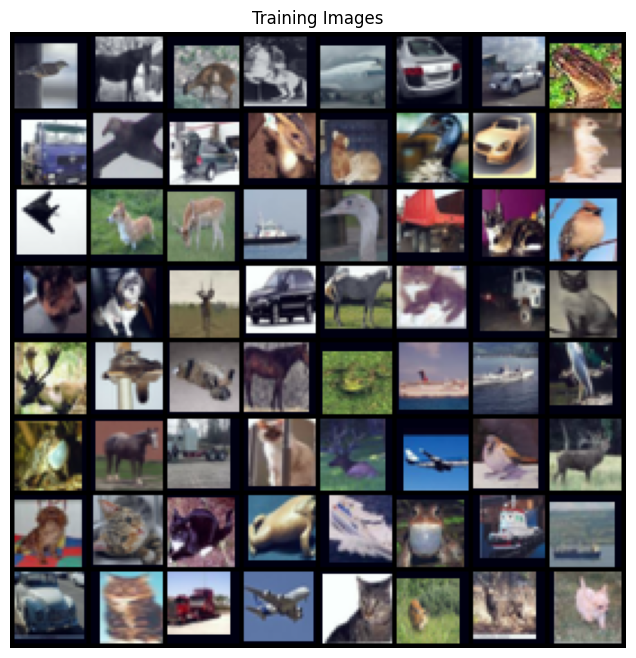

In [11]:
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(torchvision.utils.make_grid(images[:64], 
                                         padding=2, normalize=True),
                        (1, 2, 0)))

---
# 2. Model Creation

---
**Notes:**

1. **The MobileNetV1 Building Block:**
    - The defining feature of V1 is the **"Depthwise Separable"** block, which splits a standard convolution into a spatial filter (Depthwise) and a channel combiner (Pointwise).

In [12]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride, 
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, 
                      padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class MobileNetV1(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNetV1, self).__init__()

        # Initial standard convolution
        # Stride=1 for CIFAR (originally 2 in paper)
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # (in_channels, out_channels, stride)
            DepthwiseSeparableConv(32, 64, 1),
            DepthwiseSeparableConv(64, 128, 1), # Changed from stride 2 to 1
            DepthwiseSeparableConv(128, 128, 1),
            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),
            DepthwiseSeparableConv(256, 512, 2),
            
            # The 5 identical layers from the paper
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),

            DepthwiseSeparableConv(512, 1024, 2),
            DepthwiseSeparableConv(1024, 1024, 1),
            
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [13]:
model = MobileNetV1().to(device)

In [14]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
MobileNetV1                              [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 1024, 1, 1]         --                        --                        --
│    └─Conv2d: 2-1                       [128, 3, 32, 32]          [128, 32, 32, 32]         864                       [3, 3]                    113,246,208
│    └─BatchNorm2d: 2-2                  [128, 32, 32, 32]         [128, 32, 32, 32]         64                        --                        8,192
│    └─ReLU: 2-3                         [128, 32, 32, 32]         [128, 32, 32, 32]         --                        --                        --
│    └─DepthwiseSeparableConv: 2-4       [128, 32, 32, 32]         [128, 64, 32, 32]         

---
# 3. Model Training, Testing & Evaluation

---

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4) # Use weight decay (L2) to combat overfitting
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)
    
    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}')
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/50 | Train Loss: 1.64079, Train Acc.: 48.22% | Val Loss: 1.46047, Val Acc.: 46.86% | 
Epoch 2/50 | Train Loss: 1.25678, Train Acc.: 58.51% | Val Loss: 1.20850, Val Acc.: 57.16% | 
Epoch 3/50 | Train Loss: 1.02700, Train Acc.: 68.01% | Val Loss: 0.97419, Val Acc.: 65.02% | 
Epoch 4/50 | Train Loss: 0.85995, Train Acc.: 73.91% | Val Loss: 0.82695, Val Acc.: 71.44% | 
Epoch 5/50 | Train Loss: 0.74043, Train Acc.: 76.74% | Val Loss: 0.75273, Val Acc.: 73.78% | 
Epoch 6/50 | Train Loss: 0.65644, Train Acc.: 78.99% | Val Loss: 0.69230, Val Acc.: 75.56% | 
Epoch 7/50 | Train Loss: 0.60376, Train Acc.: 79.54% | Val Loss: 0.69671, Val Acc.: 76.58% | 
Epoch 8/50 | Train Loss: 0.55649, Train Acc.: 81.78% | Val Loss: 0.62899, Val Acc.: 78.00% | 
Epoch 9/50 | Train Loss: 0.51982, Train Acc.: 83.25% | Val Loss: 0.61162, Val Acc.: 79.56% | 
Epoch 10/50 | Train Loss: 0.48877, Train Acc.: 83.92% | Val Loss: 0.57651, Val Acc.: 79.40% | 
Epoch 11/50 | Train Loss: 0.45

In [16]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

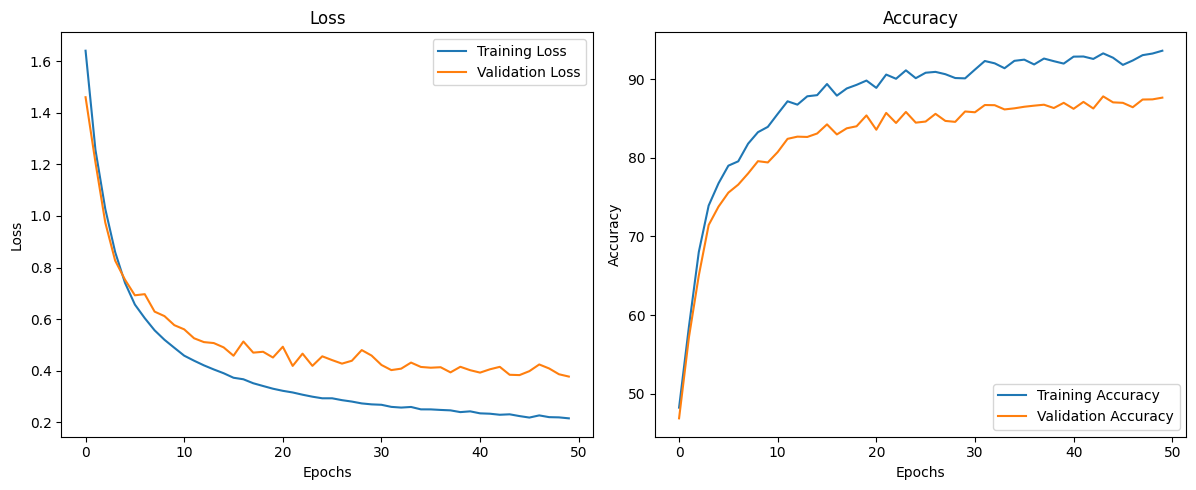

In [17]:
plot_history(history)

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _compute_confusion_matrix(model, data_loader, device):
    """
    Computes a confusion matrix for the given model and data.
    Uses scikit-learn for robustness and speed.
    """
    model.eval()
    all_targets = []
    all_predictions = []
    
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            
            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)
            
            # Move to CPU and convert to list/numpy immediately
            all_targets.extend(targets.view(-1).cpu().numpy())
            all_predictions.extend(predicted_labels.view(-1).cpu().numpy())

    return confusion_matrix(all_targets, all_predictions)

def _plot_confusion_matrix(mat, class_names):
    """
    Visualizes the confusion matrix using Seaborn for professional reporting.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: MobileNetV2 on CIFAR-10')
    plt.show()

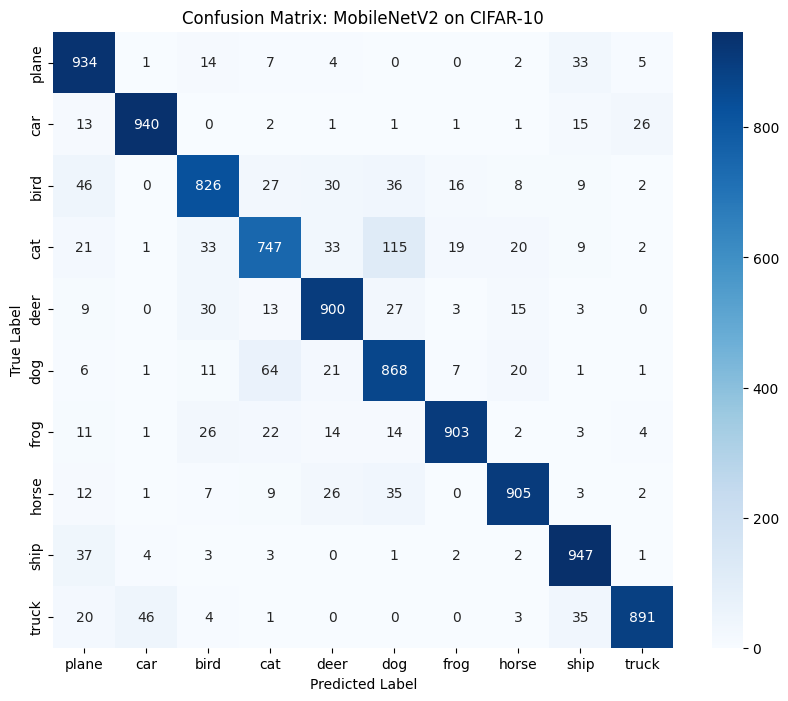

In [21]:
class_dict = {0: 'plane',
              1: 'car',
              2: 'bird',
              3: 'cat',
              4: 'deer',
              5: 'dog',
              6: 'frog',
              7: 'horse',
              8: 'ship',
              9: 'truck'}
_mat = _compute_confusion_matrix(model=model, data_loader=test_loader, device=device)
_plot_confusion_matrix(_mat, class_names=class_dict.values())

In [22]:
%watermark -iv

matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.8.0+cu126
torchinfo  : 1.8.0
torchvision: 0.23.0+cu126

